<a href="https://colab.research.google.com/github/ammmanism/ml-from-scratch-lab/blob/dev/notebooks/02_tree_models/Decision_Trees_ID3_Algorithm_Explained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Non-Linear Learning: High-Fidelity Decision Trees

Decision Trees represent one of the most intuitive yet mathematically robust classes of supervised learning. Unlike linear models that attempt to find a singular global hyperplane, tree-based estimators utilize **Recursive Axis-Parallel Partitioning** to decompose the feature space into a hierarchy of pure subsets.

### The Architecture of Intelligence
In this exploration, we bridge the gap between abstract Information Theory and production-grade Machine Learning. We will construct an ID3 engine from first principles to understand the mechanics of **Greedy Optimization**, then transition to Scikit-Learn's CART implementation to master the art of **Regularization** and **Decision Boundary Topology**.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

# Machine Learning libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons, make_classification

# Set plotting style for elite-level visual clarity
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully. Environment is ready!")

Libraries imported successfully. Environment is ready!


## The Geometry of Separation: Why Trees Excel where Linear Models Fail

Traditional linear estimators (Logistic Regression, Linear SVMs) operate under the assumption of **Linear Separability**. They attempt to bisect the entire feature space with a single $n$-dimensional slice. However, real-world data is often riddled with **interaction effects**—where the relationship between a feature and the target changes based on another feature.

### Intuition: The 'Staircase' Approximation
Decision Trees do not search for a global solution. Instead, they perform local 'if-then-else' cuts. Geometrically, this results in a series of rectangles (or hyper-rectangles) that can wrap around complex, non-linear distributions. This makes them exceptionally powerful for capturing the 'Swiss-cheese' or 'Moon' topologies of high-dimensional data.

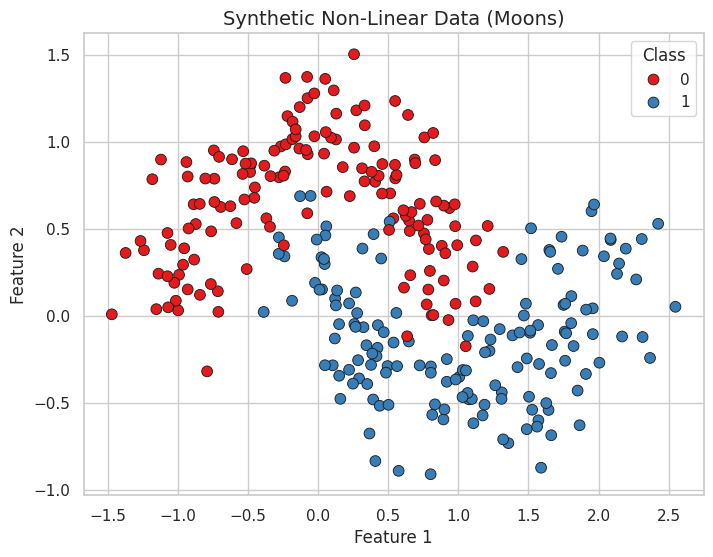

In [ ]:
# Generate a non-linear "moons" dataset
X_demo, y_demo = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_demo[:, 0], y=X_demo[:, 1], hue=y_demo, palette='Set1', edgecolor='k', s=60)
plt.title("Synthetic Non-Linear Data (Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.show()

# A linear model would try to draw a straight line through this, failing to capture the curves.
# A decision tree will slice this space into rectangular blocks to isolate the classes.

## Foundations of Information Theory: Shannon Entropy

At the heart of a Decision Tree is the concept of **Entropy ($H$)**, a measure of 'disorder' or 'uncertainty' within a system. Borrowed from thermodynamics and communication theory, entropy quantifies how much 'surprise' is contained in a set of labels.

### Mathematical Intuition
For a set $S$, Entropy is calculated as:
$$H(S) = - \sum_{i=1}^{c} p_i \log_2 p_i$$

*   **High Entropy ($H \approx 1$):** A chaotic node where classes are mixed 50/50. Here, the model has no predictive confidence.
*   **Zero Entropy ($H = 0$):** A 'pure' leaf node where every instance belongs to the same class. This is the ultimate goal of the training process.

By minimizing entropy, the model effectively 'distills' information, turning raw, noisy data into organized, certain knowledge.

In [ ]:
def calculate_entropy(target_col):
    """
    Calculates the Shannon Entropy of a dataset.

    Parameters:
    target_col (pd.Series or np.array): The target variable column.

    Returns:
    float: The entropy value.
    """
    # Find unique classes and their frequencies
    elements, counts = np.unique(target_col, return_counts=True)

    # Calculate entropy using the formula
    entropy = np.sum([
        (-counts[i] / np.sum(counts)) * np.log2(counts[i] / np.sum(counts))
        for i in range(len(elements))
    ])

    return entropy

# Test on a pure and an impure array
pure_target = np.array([1, 1, 1, 1])
impure_target = np.array([1, 1, 0, 0])

print(f"Entropy of pure dataset: {calculate_entropy(pure_target):.4f}")
print(f"Entropy of 50/50 dataset: {calculate_entropy(impure_target):.4f}")

Entropy of pure dataset: 0.0000
Entropy of 50/50 dataset: 1.0000


## Maximizing Knowledge: The Information Gain Heuristic

If Entropy is the measure of messiness, **Information Gain (IG)** is the measure of 'cleanup efficiency'. It represents the reduction in entropy achieved by partitioning the data on a specific attribute $A$.

### The Optimization Objective
Decision Trees are **Greedy Algorithms**. At every node, the tree asks: *"Which feature, if used to split the data right now, will maximize my clarity?"*

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

We subtract the weighted entropy of the potential children from the parent's entropy. The feature with the highest IG is chosen as the pivot, ensuring that each step down the tree hierarchy yields the most 'bang for the buck' in terms of classification accuracy.

In [ ]:
def information_gain(data, split_attribute_name, target_name="class"):
    """
    Calculates the Information Gain of splitting the data on a specific attribute.
    """
    # 1. Calculate the total entropy of the original dataset
    total_entropy = calculate_entropy(data[target_name])

    # 2. Calculate the values and counts for the split attribute
    vals, counts = np.unique(data[split_attribute_name], return_counts=True)

    # 3. Calculate the weighted entropy of the split
    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) * calculate_entropy(data.where(data[split_attribute_name] == vals[i]).dropna()[target_name])
        for i in range(len(vals))
    ])

    # 4. Information Gain is the reduction in entropy
    ig = total_entropy - weighted_entropy
    return ig

print("Information Gain function ready.")

Information Gain function ready.


## Empirical Case Study: Deconstructing 'Play Tennis'

To see ID3 in action, we analyze the 'Play Tennis' dataset—a canonical benchmark in ML pedagogy. This dataset serves as a perfect microcosm for **Multi-Variate Categorical Analysis**.

We aren't just looking for correlations; we are looking for the **Optimal Decision Path**. Does 'Outlook' provide more initial clarity than 'Wind'? By calculating the IG for every environmental factor, we allow the data to dictate its own logical structure, revealing the hidden 'rules' that govern the system.

In [ ]:
# Constructing the Play Tennis Dataset
dataset = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df_tennis = pd.DataFrame(dataset)
display(df_tennis)

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


### Analyzing the Initial Split

Before the tree can grow, it must determine the **Root Node**. This involves calculating the baseline entropy of the entire training set and then evaluating the Information Gain for every available feature. The feature that 'cleans' the data the most is promoted to the top of the hierarchy.

In [ ]:
# Calculate baseline entropy
baseline_entropy = calculate_entropy(df_tennis['PlayTennis'])
print(f"Baseline Entropy of the entire dataset: {baseline_entropy:.4f}")

# Calculate Information Gain for each feature
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
ig_dict = {}

for feature in features:
    ig = information_gain(df_tennis, feature, target_name='PlayTennis')
    ig_dict[feature] = ig
    print(f"Information Gain for {feature}: {ig:.4f}")

# Select the best feature
best_feature = max(ig_dict, key=ig_dict.get)
print(f"\n🏆 The root node will be: **{best_feature}** (Highest Information Gain)")

Baseline Entropy of the entire dataset: 0.9403
Information Gain for Outlook: 0.2467
Information Gain for Temperature: 0.0292
Information Gain for Humidity: 0.1518
Information Gain for Wind: 0.0481

🏆 The root node will be: **Outlook** (Highest Information Gain)


## The ID3 Engine: Recursive Induction & Base Cases

The implementation of the ID3 algorithm is a masterclass in **Recursive Programming**. The algorithm behaves like a fractal, applying the same logic to smaller and smaller subsets of data until it reaches a logical dead end.

### The 'Elite' Stopping Logic
To prevent infinite loops and ensure robust logic, we implement three critical base cases:
1.  **Absolute Purity:** All remaining data points share a class. We stop and label the leaf.
2.  **Attribute Depletion:** We have run out of features to split on, but the data isn't pure. We take a 'majority vote'—handling noise gracefully.
3.  **Path Nullification:** A branch is created for a category that didn't exist in the training slice. We inherit the parent's majority class to maintain a 'best guess' capability.

In [ ]:
def id3(data, original_data, features, target_attribute_name="PlayTennis", parent_node_class=None):
    """
    Recursive function to build the ID3 Decision Tree.
    """
    # Base Case 1: If all target values are the same, return that value
    if len(np.unique(data[target_attribute_name])) <= 1:
        return np.unique(data[target_attribute_name])[0]

    # Base Case 2: If dataset is empty, return the mode target feature value in the original dataset
    elif len(data) == 0:
        return np.unique(original_data[target_attribute_name])[np.argmax(np.unique(original_data[target_attribute_name], return_counts=True)[1])]

    # Base Case 3: If feature space is empty, return the majority class of the parent node
    elif len(features) == 0:
        return parent_node_class

    # Recursive Step: Grow the tree
    else:
        # Determine the majority class of the current node (to pass to children as parent_node_class)
        parent_node_class = np.unique(data[target_attribute_name])[np.argmax(np.unique(data[target_attribute_name], return_counts=True)[1])]

        # Select the feature which best splits the dataset
        item_values = [information_gain(data, feature, target_attribute_name) for feature in features]
        best_feature_index = np.argmax(item_values)
        best_feature = features[best_feature_index]

        # Create the tree structure as a nested dictionary
        tree = {best_feature: {}}

        # Remove the chosen feature from the feature space
        features = [i for i in features if i != best_feature]

        # Grow a branch under the root node for each possible value of the root node feature
        for value in np.unique(data[best_feature]):
            sub_data = data.where(data[best_feature] == value).dropna()
            # Recursion
            subtree = id3(sub_data, original_data, features, target_attribute_name, parent_node_class)
            # Add subtree to the main tree
            tree[best_feature][value] = subtree

        return tree

print("ID3 recursive algorithm defined successfully.")

ID3 recursive algorithm defined successfully.


### 4.1 Training and Visualizing the Custom Tree
Let's pass our dataset into our `id3` function. The output will be a nested dictionary representing the rules of the tree.

In [ ]:
# Define features and train the tree
feature_cols = df_tennis.columns[:-1].tolist()
custom_tree = id3(df_tennis, df_tennis, feature_cols, target_attribute_name="PlayTennis")

print("Trained ID3 Decision Tree Structure:\n")
pprint(custom_tree)

Trained ID3 Decision Tree Structure:

{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


## Logical Inference: The Art of Tree Traversal

A trained Decision Tree is effectively a **Compiled Rulebook**. While the training phase (induction) is computationally expensive, the prediction phase (inference) is incredibly fast, operating at $O(depth)$ complexity.

### Intuition of the Query Path
For every new sample, we start at the root and perform a 'Plinko' style descent. Each node is a gatekeeper, checking a specific feature and funneling the sample down the corresponding branch. This deterministic path-finding is what makes Decision Trees the most 'explainable' models in AI—you can literally trace the 'why' behind every single prediction.

In [ ]:
def predict_custom_tree(query, tree, default="Yes"):
    """
    Predicts the class for a new query using the trained nested-dictionary tree.
    """
    for key in list(query.keys()):
        if key in list(tree.keys()):
            try:
                result = tree[key][query[key]]
            except KeyError:
                # Handle unseen categorical values gracefully
                return default

            # If the result is a dict, we haven't reached a leaf node yet
            if isinstance(result, dict):
                return predict_custom_tree(query, result)
            else:
                return result

# Test prediction on a new unseen day
new_day = {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong'}
prediction = predict_custom_tree(new_day, custom_tree)
print(f"Prediction for query {new_day}:\n=> PlayTennis: {prediction}")

Prediction for query {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong'}:
=> PlayTennis: Yes


## Transitioning to CART: Continuous Threshold Optimization

While ID3 excels at categorical logic, the **CART (Classification and Regression Trees)** algorithm used by Scikit-Learn introduces the ability to handle **Numerical Features**.

### Intuition: Binary Binary Splitting
Instead of splitting on fixed categories, CART treats numerical features as a series of potential binary gates ($X < threshold$). It iterates through every unique value in the dataset, testing it as a potential split point to see which threshold maximizes the Gini Impurity or Entropy reduction. This allows the tree to create sophisticated 'step-function' boundaries in a continuous coordinate system.

In [ ]:
# Generate a more complex, numerical classification dataset
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (350, 2)
Testing data shape: (150, 2)


### 5.1 Gini Impurity vs. Entropy
Scikit-learn uses **Gini Impurity** by default instead of Entropy.
$$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
**Why Gini?** It is computationally faster because it doesn't require calculating logarithms. In practice, Gini and Entropy yield extremely similar trees. For this tutorial, we will set `criterion='entropy'` to mirror our ID3 logic.

In [ ]:
# Instantiate the Decision Tree Classifier
# We restrict max_depth to prevent overfitting (we will discuss this soon)
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# Train the model
clf.fit(X_train, y_train)

print("Scikit-Learn Decision Tree trained successfully!")

Scikit-Learn Decision Tree trained successfully!


## Gini Impurity: The Speed of Production ML

In Scikit-Learn, the default metric is **Gini Impurity** rather than Entropy.
$$Gini = 1 - \sum (p_i)^2$$

### Why the Shift?
Entropy involves logarithmic calculations, which are computationally 'heavy' for processors. Gini Impurity, being a simple squared-probability sum, is much faster to compute during the thousands of split-evaluations required for large datasets. Theoretically, they are nearly identical; Gini focuses on minimizing the probability of misclassification, leading to highly efficient, high-performance trees.

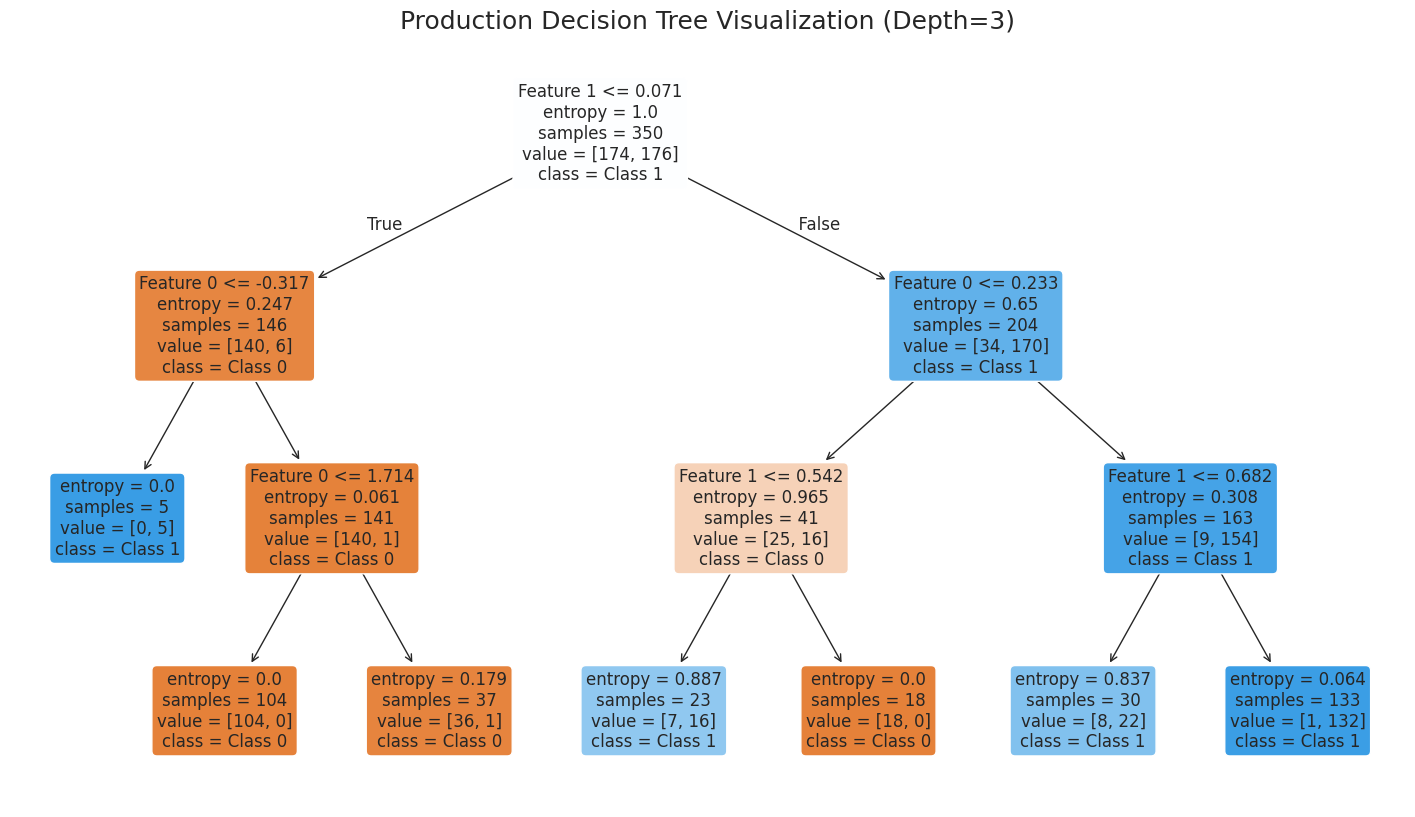

In [ ]:
plt.figure(figsize=(18, 10))
plot_tree(clf,
          filled=True,
          rounded=True,
          class_names=['Class 0', 'Class 1'],
          feature_names=['Feature 0', 'Feature 1'],
          fontsize=12)
plt.title("Production Decision Tree Visualization (Depth=3)", fontsize=18)
plt.show()

## Visualizing the Decision Manifold

When we plot the decision boundary of a tree, we witness its **Inductive Bias**. Because each split is based on a single feature, the boundaries are always parallel to the axes.

### The 'Over-Fitted' Staircase
A deep tree will try to create tiny 'boxes' to isolate every single outlier. This visualization is our primary diagnostic tool: if we see extremely narrow, jagged segments, our model is likely **memorizing noise** (High Variance) rather than **learning signal**. This leads us to the critical need for Pruning.

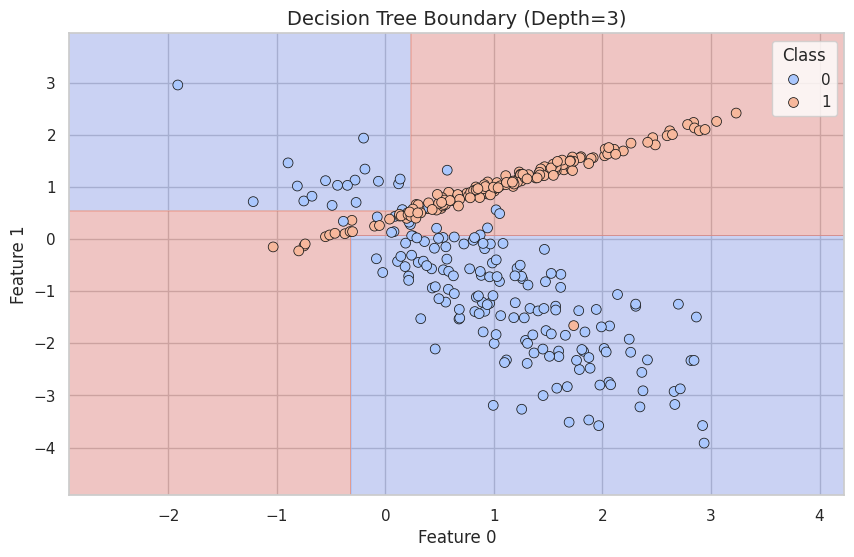

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plots the decision boundary of a trained model."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict over the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='coolwarm', edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.legend(title="Class")
    plt.show()

plot_decision_boundary(clf, X_train, y_train, "Decision Tree Boundary (Depth=3)")

## Structural Overfitting: The High-Variance Trap

A Decision Tree is fundamentally 'hungry'. Without constraints, it will continue to split until every leaf is perfectly pure, effectively creating a lookup table for the training data. This is **Overfitting**.

### Pruning: The Zen of Constraint
To build a model that survives the 'Real World', we must enforce **Structural Regularization**:
*   **Max Depth:** Limits the 'levels' of the hierarchy, forcing the tree to find broader, more general patterns.
*   **Min Samples per Leaf:** Prevents the tree from making a decision based on only 1 or 2 outlier points.

By 'cutting' the branches, we trade a bit of training accuracy for a massive gain in **Generalization Performance**.

Unconstrained Tree Training Accuracy: 100.00%
Unconstrained Tree Testing Accuracy: 95.33%


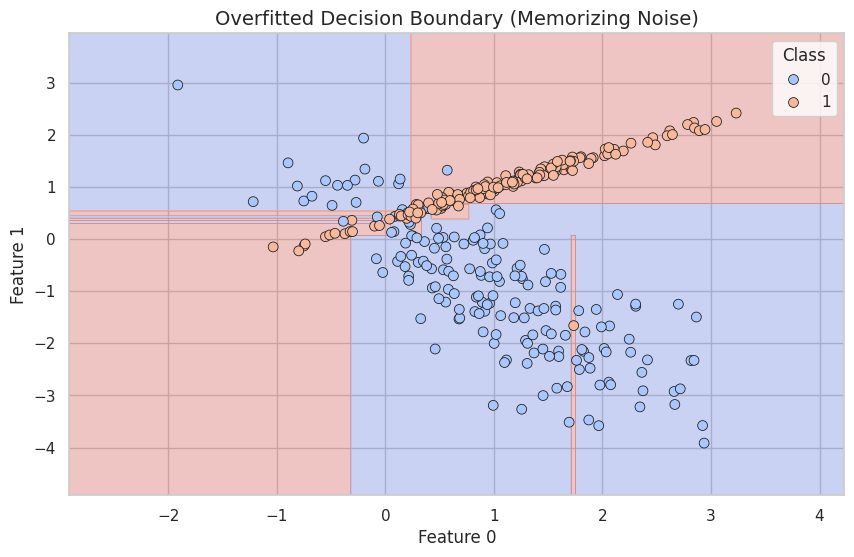

In [ ]:
# Let's train an UNCONSTRAINED tree to demonstrate overfitting
clf_overfit = DecisionTreeClassifier(criterion='entropy', random_state=42) # No max_depth!
clf_overfit.fit(X_train, y_train)

print(f"Unconstrained Tree Training Accuracy: {accuracy_score(y_train, clf_overfit.predict(X_train)) * 100:.2f}%")
print(f"Unconstrained Tree Testing Accuracy: {accuracy_score(y_test, clf_overfit.predict(X_test)) * 100:.2f}%")

# The training accuracy will likely be 100%, but testing accuracy will be lower.
plot_decision_boundary(clf_overfit, X_train, y_train, "Overfitted Decision Boundary (Memorizing Noise)")

## Beyond the Score: Decoding Model Performance

Accuracy is a deceptive metric. To truly evaluate a Decision Tree, we must perform a **Decomposition of Errors**. We use the **Classification Report** and the **Confusion Matrix** to understand where the model's logic is brittle.

### The Confusion Matrix: A Map of Failure
The Confusion Matrix allows us to see the **Type I (False Positives)** and **Type II (False Negatives)** errors. For a tree, a cluster of errors often signifies a region of the feature space where classes are highly interleaved, or where the 'staircase' boundary is too coarse to capture the true underlying distribution. By analyzing these misclassifications, we can determine if we need more depth, or if we need to engineer better features.

Pruned Tree Testing Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94        75
           1       0.90      0.99      0.94        75

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



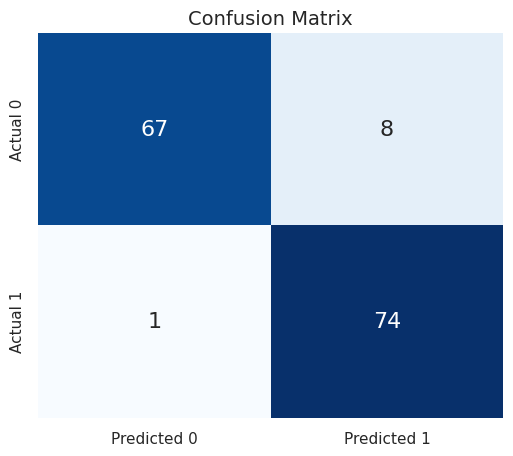

In [ ]:
# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Pruned Tree Testing Accuracy: {acc * 100:.2f}%\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.show()

## The Path Forward: From Single Trees to Ensemble Dominance

We have successfully traversed the journey from the theoretical math of Information Gain to a production-ready scikit-learn model. However, a single Decision Tree is rarely the final stop in a high-stakes ML pipeline.

### Elite Practical Insights for the Professional Architect:

1.  **Feature Scaling Invariance**: Unlike Distance-based models (KNN, SVM) or Gradient-based models (Neural Networks), Decision Trees are **Monotonic Transformation Invariant**. You do not need to normalize or standardize your data; the tree only cares about the relative ordering of values, making it exceptionally robust to outliers.
2.  **The Curse of Variance**: A single tree is a 'Weak Learner'. It is highly sensitive to small fluctuations in the training data. A single point change can ripple up the recursion and change the root node entirely.
3.  **Ensemble Methods (The GOAT Tier)**: To solve the variance problem, we combine trees into **Forests**.
    *   **Bagging (Random Forest)**: Trains multiple deep trees on different subsets of data and averages them to cancel out noise.
    *   **Boosting (XGBoost/LightGBM)**: Trains trees sequentially, where each new tree specifically targets the errors of the previous one.

**Final Verdict**: Master the single tree to understand the logic; master the ensemble to conquer the data.

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://www.chegg.com/homework-help/questions-and-answers/apply-iterative-dichotomiser-3-algorithm-construct-decision-tree-following-dataset-index-2-q72314650">https://www.chegg.com/homework-help/questions-and-answers/apply-iterative-dichotomiser-3-algorithm-construct-decision-tree-following-dataset-index-2-q72314650</a></li>
  <li><a href="https://www.chegg.com/homework-help/questions-and-answers/5-answer-following-questions-based-upon-training-examples-shown-table-binary-classificatio-q90799080">https://www.chegg.com/homework-help/questions-and-answers/5-answer-following-questions-based-upon-training-examples-shown-table-binary-classificatio-q90799080</a></li>
  </ol>
</div>